# Experiment Bot — Analysis Pipeline
Compute behavioral metrics from bot output and compare to human reference data.

In [ ]:
import hashlib
import json
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
HUMAN_DIR = ROOT / 'data' / 'human'
OUTPUT_DIR = ROOT / 'output'
CACHE_DIR = ROOT / 'cache'

def generate_sub_id(seed_str: str) -> str:
    """Generate a 24-char lowercase hex ID resembling a Prolific subject ID."""
    return hashlib.sha256(seed_str.encode()).hexdigest()[:24]

def load_experiment_data(path):
    """Load experiment data from CSV or JSON."""
    p = Path(path)
    if p.suffix == '.json':
        with open(p) as f:
            return pd.DataFrame(json.load(f))
    return pd.read_csv(p)

def load_cached_config(label):
    """Load cached config and extract Claude's expected parameters."""
    config_path = CACHE_DIR / label / 'config.json'
    if not config_path.exists():
        print(f"  WARNING: No cached config for {label}")
        return None
    with open(config_path) as f:
        return json.load(f)

def display_config_params(config, label):
    """Display Claude's expected behavioral parameters from the cached config."""
    if config is None:
        return
    print(f"=== Claude's Expected Parameters ({label}) ===")
    rd = config.get('response_distributions', {})
    for cond, dist in rd.items():
        p = dist.get('params', {})
        print(f"  {cond}: mu={p.get('mu')}, sigma={p.get('sigma')}, tau={p.get('tau')}")
    perf = config.get('performance', {})
    print(f"  Accuracy targets: {perf.get('accuracy', {})}")
    print(f"  Omission targets: {perf.get('omission_rate', {})}")
    te = config.get('temporal_effects', {})
    enabled = [k for k, v in te.items() if isinstance(v, dict) and v.get('enabled')]
    if enabled:
        print(f"  Temporal effects enabled: {enabled}")
    bsj = config.get('between_subject_jitter', {})
    if bsj.get('rt_mean_sd_ms'):
        print(f"  Between-subject jitter: rt_mean_sd={bsj['rt_mean_sd_ms']}ms")
    print()

def find_latest_run(task_dir_pattern):
    """Find the latest run directory matching a pattern."""
    matches = sorted(OUTPUT_DIR.glob(task_dir_pattern + '/*/experiment_data.*'))
    if not matches:
        return None
    return matches[-1].parent

def find_all_runs(task_dir_pattern):
    """Find ALL run directories matching a pattern, sorted oldest to newest."""
    matches = sorted(OUTPUT_DIR.glob(task_dir_pattern + '/*/experiment_data.*'))
    return [m.parent for m in matches]

def summary_table(df, metrics):
    """Mean +/- SD summary for each metric across subjects."""
    rows = []
    for col in metrics:
        if col not in df.columns:
            rows.append({'metric': col, 'mean': float('nan'), 'sd': float('nan'), 'n': 0})
            continue
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        rows.append({'metric': col, 'mean': round(series.mean(), 4), 'sd': round(series.std(ddof=1), 4), 'n': len(series)})
    return pd.DataFrame(rows).set_index('metric')


def find_latest_run_by_name(task_dir_name):
    """Find the latest run directory for a task dir with an exact name.
    Use instead of find_latest_run when the dir name contains parentheses,
    which Python 3.12 pathlib.glob treats as group syntax rather than literals."""
    task_dir = OUTPUT_DIR / task_dir_name
    if not task_dir.exists():
        return None
    matches = sorted(task_dir.glob('*/experiment_data.*'))
    if not matches:
        return None
    return matches[-1].parent

def find_all_runs_by_name(task_dir_name):
    """Find ALL run directories for a task dir with an exact name."""
    task_dir = OUTPUT_DIR / task_dir_name
    if not task_dir.exists():
        return []
    matches = sorted(task_dir.glob('*/experiment_data.*'))
    return [m.parent for m in matches]

print(f"ROOT: {ROOT}")
print(f"Output dirs: {sorted([p.name for p in OUTPUT_DIR.iterdir() if p.is_dir()])}")
for task_dir in sorted(OUTPUT_DIR.iterdir()):
    if task_dir.is_dir():
        runs = [d for d in task_dir.iterdir() if d.is_dir()]
        print(f"  {task_dir.name}: {len(runs)} runs")

ROOT: /Users/loganbennett/Downloads/experiment_bot
Output dirs: ['stop_signal_task_(rdoc)', 'stop_signal_task_(stop-it)', 'stroop_color-word_task', 'stroop_color-word_task_(rdoc)']
  stop_signal_task_(rdoc): 29 runs
  stop_signal_task_(stop-it): 29 runs
  stroop_color-word_task: 28 runs
  stroop_color-word_task_(rdoc): 29 runs


## Human Reference Data
Load Eisenberg et al. (2019) Self Regulation Battery trial-level data. Compute session-level metrics per subject for comparison with bot data, and retain trial-level data for sequential effects analysis.

In [ ]:
# --- Load human reference data from Eisenberg et al. (2019) archive ---
# Tries trial-level Eisenberg data (data/human/stop_signal.csv) first;
# if not present (gitignored due to size), falls back to session-level archive.

_ss_trial_path = HUMAN_DIR / 'stop_signal.csv'
_st_trial_path = HUMAN_DIR / 'stroop.csv'
_ss_archive_path = HUMAN_DIR / 'archive_rdoc' / 'stop_signal.csv'
_st_archive_path = HUMAN_DIR / 'archive_rdoc' / 'stroop.csv'

USING_TRIAL_LEVEL = _ss_trial_path.exists() and _st_trial_path.exists()

if USING_TRIAL_LEVEL:
    # ---- Trial-level Eisenberg 2019 path ----
    ss_trials_raw = pd.read_csv(_ss_trial_path)
    stroop_trials_raw = pd.read_csv(_st_trial_path)

    ss_test = ss_trials_raw[ss_trials_raw['exp_stage'] == 'test'].copy()
    ss_test['rt'] = pd.to_numeric(ss_test['rt'], errors='coerce')
    stroop_test = stroop_trials_raw[stroop_trials_raw['exp_stage'] == 'test'].copy()
    stroop_test['rt'] = pd.to_numeric(stroop_test['rt'], errors='coerce')

    print(f"Stop Signal (trial-level): {len(ss_test)} test trials, {ss_test['worker_id'].nunique()} subjects")
    print(f"Stroop (trial-level): {len(stroop_test)} test trials, {stroop_test['worker_id'].nunique()} subjects")

    ss_human_rows = []
    for subj, sdf in ss_test.groupby('worker_id'):
        go = sdf[sdf['SS_trial_type'] == 'go']
        stop = sdf[sdf['SS_trial_type'] == 'stop']
        correct_go = go[go['correct'] == 1]
        failed_stop = stop[stop['correct'] == 0]
        go_responded = go[go['rt'] > 0]
        go_omissions = go[go['stopped'] == True]
        ss_human_rows.append({
            'sub_id': subj,
            'go_accuracy': go['correct'].mean(),
            'go_omission_rate': len(go_omissions) / len(go) if len(go) > 0 else np.nan,
            'go_rt': correct_go['rt'].mean(),
            'go_rt_all_responses': go_responded['rt'].mean(),
            'mean_stop_failure_RT': failed_stop['rt'].mean() if len(failed_stop) > 0 else np.nan,
            'stop_accuracy': stop['correct'].mean(),
            'max_SSD': stop['SS_delay'].max(),
            'mean_SSD': stop['SS_delay'].mean(),
            'min_SSD': stop['SS_delay'].min(),
            'final_SSD': stop['SS_delay'].iloc[-1] if len(stop) > 0 else np.nan,
        })
    ss_human = pd.DataFrame(ss_human_rows)
    ss_human['ssrt'] = ss_human['go_rt'] - ss_human['mean_SSD']

    stroop_human_rows = []
    for subj, sdf in stroop_test.groupby('worker_id'):
        cong = sdf[sdf['condition'] == 'congruent']
        incong = sdf[sdf['condition'] == 'incongruent']
        correct_cong = cong[cong['correct'] == 1]
        correct_incong = incong[incong['correct'] == 1]
        stroop_human_rows.append({
            'sub_id': subj,
            'congruent_accuracy': cong['correct'].mean(),
            'congruent_omission_rate': (cong['rt'] < 0).mean() if len(cong) > 0 else np.nan,
            'congruent_rt': correct_cong['rt'].mean(),
            'incongruent_accuracy': incong['correct'].mean(),
            'incongruent_omission_rate': (incong['rt'] < 0).mean() if len(incong) > 0 else np.nan,
            'incongruent_rt': correct_incong['rt'].mean(),
        })
    stroop_human = pd.DataFrame(stroop_human_rows)
    stroop_human['stroop_effect'] = stroop_human['incongruent_rt'] - stroop_human['congruent_rt']

else:
    # ---- Session-level archive fallback (RDoC battery pre-computed metrics) ----
    # Apply exclusion filter: all three exclusion columns must equal 'Include'
    print("Eisenberg 2019 trial-level data not found. Using session-level archive (data/human/archive_rdoc/).")
    _excl_cols = ['Session-Level Exclusions', 'Task-Level Exclusions', 'Subject-Level Exclusions']

    ss_raw = pd.read_csv(_ss_archive_path)
    # Drop the header row that was accidentally included as a data row
    ss_raw = ss_raw[ss_raw['sub_id'] != 'sub_id'].copy()
    ss_incl = ss_raw[(ss_raw[_excl_cols[0]] == 'Include') &
                     (ss_raw[_excl_cols[1]] == 'Include') &
                     (ss_raw[_excl_cols[2]] == 'Include')].copy()
    for col in ['go_accuracy', 'go_omission_rate', 'go_rt', 'go_rt_all_responses',
                'mean_stop_failure_RT', 'stop_accuracy', 'max_SSD', 'mean_SSD', 'min_SSD', 'final_SSD']:
        ss_incl[col] = pd.to_numeric(ss_incl[col], errors='coerce')
    ss_human = ss_incl[['sub_id', 'go_accuracy', 'go_omission_rate', 'go_rt', 'go_rt_all_responses',
                         'mean_stop_failure_RT', 'stop_accuracy', 'max_SSD', 'mean_SSD', 'min_SSD', 'final_SSD']].copy()
    ss_human['ssrt'] = ss_human['go_rt'] - ss_human['mean_SSD']
    print(f"Stop Signal (archive, included): {len(ss_human)} subjects")

    st_raw = pd.read_csv(_st_archive_path)
    st_raw = st_raw[st_raw['sub_id'] != 'sub_id'].copy()
    st_incl = st_raw[(st_raw[_excl_cols[0]] == 'Include') &
                     (st_raw[_excl_cols[1]] == 'Include') &
                     (st_raw[_excl_cols[2]] == 'Include')].copy()
    for col in ['congruent_accuracy', 'congruent_omission_rate', 'congruent_rt',
                'incongruent_accuracy', 'incongruent_omission_rate', 'incongruent_rt']:
        st_incl[col] = pd.to_numeric(st_incl[col], errors='coerce')
    stroop_human = st_incl[['sub_id', 'congruent_accuracy', 'congruent_omission_rate', 'congruent_rt',
                             'incongruent_accuracy', 'incongruent_omission_rate', 'incongruent_rt']].copy()
    stroop_human['stroop_effect'] = stroop_human['incongruent_rt'] - stroop_human['congruent_rt']
    print(f"Stroop (archive, included): {len(stroop_human)} subjects")

    # Stub ss_test / stroop_test for downstream cells that use trial-level data
    ss_test = pd.DataFrame()
    stroop_test = pd.DataFrame()

SS_METRICS = ['go_accuracy', 'go_omission_rate', 'go_rt', 'go_rt_all_responses',
              'mean_stop_failure_RT', 'stop_accuracy', 'max_SSD', 'mean_SSD', 'min_SSD', 'final_SSD']
STROOP_METRICS = ['congruent_accuracy', 'congruent_omission_rate', 'congruent_rt',
                  'incongruent_accuracy', 'incongruent_omission_rate', 'incongruent_rt']

print(f"\nStop Signal: {len(ss_human)} subjects")
print(summary_table(ss_human, SS_METRICS))
print(f"\nStroop: {len(stroop_human)} subjects")
print(summary_table(stroop_human, STROOP_METRICS + ['stroop_effect']))

## 1. RDoC Stop Signal (ExpFactory)
Load cached config parameters, compute metrics from experiment output.

In [ ]:
# Load Claude's config
ss_rdoc_config = load_cached_config('expfactory_stop_signal')
display_config_params(ss_rdoc_config, 'expfactory_stop_signal')

# Find latest run
ss_rdoc_dir = find_latest_run('stop_signal_task_(rdoc)')
if ss_rdoc_dir is None:
    print("No RDoC stop signal data found. Run the bot first.")
else:
    data_file = list(ss_rdoc_dir.glob('experiment_data.*'))[0]
    print(f"Loading: {data_file}")
    df = load_experiment_data(data_file)

    test_trials = df[df['trial_id'] == 'test_trial']
    assert len(test_trials) == 180, f'Expected 180 test trials, found {len(test_trials)}'

    go_trials = test_trials[test_trials['condition'] == 'go']
    stop_trials = test_trials[test_trials['condition'] == 'stop']
    assert len(go_trials) == 120, f'Expected 120 go trials, found {len(go_trials)}'
    assert len(stop_trials) == 60, f'Expected 60 stop trials, found {len(stop_trials)}'

    correct_go = go_trials[go_trials['correct_trial'] == 1]
    incorrect_stop = stop_trials[stop_trials['correct_trial'] == 0]

    ss_rdoc_metrics = {
        'go_accuracy': len(correct_go) / len(go_trials),
        'go_omission_rate': go_trials['rt'].isna().mean(),
        'go_rt': correct_go['rt'].mean(),
        'go_rt_all_responses': go_trials['rt'].mean(),
        'mean_stop_failure_RT': incorrect_stop['rt'].mean(),
        'stop_accuracy': (stop_trials['correct_trial'] == 1).mean(),
        'max_SSD': stop_trials['SSD'].max(),
        'mean_SSD': stop_trials['SSD'].mean(),
        'min_SSD': stop_trials['SSD'].min(),
        'final_SSD': stop_trials['SSD'].iloc[-1],
    }

    print("Bot metrics:")
    for k, v in ss_rdoc_metrics.items():
        print(f"  {k}: {v:.4f}")

    # Compare to human
    print("\nBot vs Human:")
    for k in SS_METRICS:
        bot_val = ss_rdoc_metrics.get(k, float('nan'))
        h_mean = pd.to_numeric(ss_human[k], errors='coerce').mean()
        h_sd = pd.to_numeric(ss_human[k], errors='coerce').std()
        within = "YES" if abs(bot_val - h_mean) < h_sd else "NO"
        print(f"  {k:30s}  bot={bot_val:8.3f}  human={h_mean:8.3f} \u00b1{h_sd:7.3f}  within_1SD={within}")

=== Claude's Expected Parameters (expfactory_stop_signal) ===
  go: mu=430, sigma=60, tau=120
  stop_failure: mu=350, sigma=45, tau=80
  Accuracy targets: {'go': 0.92, 'stop': 0.5}
  Omission targets: {'go': 0.03, 'stop': 0.0}
  Temporal effects enabled: ['autocorrelation', 'fatigue_drift', 'post_error_slowing', 'pink_noise', 'post_interrupt_slowing']
  Between-subject jitter: rt_mean_sd=45ms

Loading: /Users/loganbennett/Downloads/experiment_bot/output/stop_signal_task_(rdoc)/2026-03-23_11-10-20/experiment_data.json
Bot metrics:
  go_accuracy: 0.9250
  go_omission_rate: 0.0750
  go_rt: 647.0270
  go_rt_all_responses: 647.0270
  mean_stop_failure_RT: 503.1034
  stop_accuracy: 0.5167
  max_SSD: 650.0000
  mean_SSD: 458.3333
  min_SSD: 250.0000
  final_SSD: 400.0000

Bot vs Human:
  go_accuracy                     bot=   0.925  human=   0.967 ±  0.047  within_1SD=YES
  go_omission_rate                bot=   0.075  human=   0.011 ±  0.027  within_1SD=NO
  go_rt                           b

## 2. RDoC Stroop (ExpFactory)
Load cached config parameters, compute metrics from experiment output.

In [ ]:
stroop_rdoc_config = load_cached_config('expfactory_stroop')
display_config_params(stroop_rdoc_config, 'expfactory_stroop')

stroop_rdoc_dir = find_latest_run('stroop_(rdoc)')
if stroop_rdoc_dir is None:
    print("No RDoC Stroop data found. Run the bot first.")
else:
    data_file = list(stroop_rdoc_dir.glob('experiment_data.*'))[0]
    print(f"Loading: {data_file}")
    df = load_experiment_data(data_file)

    test_trials = df[df['trial_id'] == 'test_trial']
    congruent = test_trials[test_trials['condition'] == 'congruent']
    incongruent = test_trials[test_trials['condition'] == 'incongruent']
    assert len(test_trials) == 120, f'Expected 120 test trials, found {len(test_trials)}'
    assert len(congruent) == 60, f'Expected 60 congruent, found {len(congruent)}'
    assert len(incongruent) == 60, f'Expected 60 incongruent, found {len(incongruent)}'

    stroop_rdoc_metrics = {
        'congruent_accuracy': (congruent['correct_trial'] == 1).mean(),
        'congruent_omission_rate': congruent['rt'].isna().mean(),
        'congruent_rt': congruent[congruent['correct_trial'] == 1]['rt'].mean(),
        'incongruent_accuracy': (incongruent['correct_trial'] == 1).mean(),
        'incongruent_omission_rate': incongruent['rt'].isna().mean(),
        'incongruent_rt': incongruent[incongruent['correct_trial'] == 1]['rt'].mean(),
    }

    print("Bot metrics:")
    for k, v in stroop_rdoc_metrics.items():
        print(f"  {k}: {v:.4f}")

    stroop_effect = stroop_rdoc_metrics['incongruent_rt'] - stroop_rdoc_metrics['congruent_rt']
    print(f"  stroop_effect: {stroop_effect:.4f}")

    print("\nBot vs Human:")
    for k in STROOP_METRICS:
        bot_val = stroop_rdoc_metrics.get(k, float('nan'))
        h_mean = pd.to_numeric(stroop_human[k], errors='coerce').mean()
        h_sd = pd.to_numeric(stroop_human[k], errors='coerce').std()
        within = "YES" if abs(bot_val - h_mean) < h_sd else "NO"
        print(f"  {k:30s}  bot={bot_val:8.3f}  human={h_mean:8.3f} \u00b1{h_sd:7.3f}  within_1SD={within}")
    h_se_mean = stroop_human['stroop_effect'].mean()
    h_se_sd = stroop_human['stroop_effect'].std()
    within = "YES" if abs(stroop_effect - h_se_mean) < h_se_sd else "NO"
    print(f"  {'stroop_effect':30s}  bot={stroop_effect:8.3f}  human={h_se_mean:8.3f} \u00b1{h_se_sd:7.3f}  within_1SD={within}")

=== Claude's Expected Parameters (expfactory_stroop) ===
  congruent: mu=520, sigma=60, tau=120
  incongruent: mu=590, sigma=70, tau=160
  Accuracy targets: {'congruent': 0.97, 'incongruent': 0.9}
  Omission targets: {'congruent': 0.01, 'incongruent': 0.02}
  Temporal effects enabled: ['autocorrelation', 'fatigue_drift', 'post_error_slowing', 'condition_repetition', 'pink_noise']
  Between-subject jitter: rt_mean_sd=45ms

Loading: /Users/loganbennett/Downloads/experiment_bot/output/stroop_color-word_task_(rdoc)/2026-03-23_11-19-29/experiment_data.csv
Bot metrics:
  congruent_accuracy: 0.9833
  congruent_omission_rate: 0.0167
  congruent_rt: 721.1525
  incongruent_accuracy: 0.9167
  incongruent_omission_rate: 0.0667
  incongruent_rt: 710.1818
  stroop_effect: -10.9707

Bot vs Human:
  congruent_accuracy              bot=   0.983  human=   0.961 ±  0.046  within_1SD=YES
  congruent_omission_rate         bot=   0.017  human=   0.004 ±  0.016  within_1SD=YES
  congruent_rt                 

## 3. STOP-IT Stop Signal
Load cached config parameters, compute metrics from experiment output.

In [ ]:
stopit_config = load_cached_config('stopit_stop_signal')
display_config_params(stopit_config, 'stopit_stop_signal')

stopit_dir = find_latest_run_by_name('stop-signal_task_(stop-it)')
if stopit_dir is None:
    print("No STOP-IT data found. Run the bot first.")
else:
    data_file = list(stopit_dir.glob('experiment_data.*'))[0]
    print(f"Loading: {data_file}")
    df = load_experiment_data(data_file)

    go_trials = df[df['signal'] == 'no']
    stop_trials = df[df['signal'] == 'yes']
    assert len(go_trials) == 216, f'Expected 216 go trials, found {len(go_trials)}'
    assert len(stop_trials) == 72, f'Expected 72 stop trials, found {len(stop_trials)}'

    stopit_metrics = {
        'go_accuracy': go_trials['correct'].mean(),
        'go_omission_rate': (go_trials['response'] == 'undefined').mean(),
        'go_rt': go_trials[go_trials['correct'] == True]['rt'].mean(),
        'go_rt_all_responses': go_trials['rt'].mean(),
        'mean_stop_failure_RT': stop_trials[stop_trials['correct'] == False]['rt'].mean(),
        'stop_accuracy': stop_trials['correct'].mean(),
        'max_SSD': stop_trials['SSD'].max(),
        'mean_SSD': stop_trials['SSD'].mean(),
        'min_SSD': stop_trials['SSD'].min(),
        'final_SSD': stop_trials.iloc[-1]['SSD'],
    }

    print("Bot metrics:")
    for k, v in stopit_metrics.items():
        print(f"  {k}: {v:.4f}")

    print("\nBot vs Human (ExpFactory reference):")
    for k in SS_METRICS:
        bot_val = stopit_metrics.get(k, float('nan'))
        h_mean = pd.to_numeric(ss_human[k], errors='coerce').mean()
        h_sd = pd.to_numeric(ss_human[k], errors='coerce').std()
        within = "YES" if abs(bot_val - h_mean) < h_sd else "NO"
        print(f"  {k:30s}  bot={bot_val:8.3f}  human={h_mean:8.3f} \u00b1{h_sd:7.3f}  within_1SD={within}")

=== Claude's Expected Parameters (stopit_stop_signal) ===
  go_left: mu=420, sigma=50, tau=90
  go_right: mu=420, sigma=50, tau=90
  failed_stop: mu=340, sigma=40, tau=60
  Accuracy targets: {'go_left': 0.96, 'go_right': 0.96, 'stop_signal': 0.5}
  Omission targets: {'go_left': 0.01, 'go_right': 0.01, 'stop_signal': 0.0}
  Temporal effects enabled: ['autocorrelation', 'fatigue_drift', 'post_error_slowing', 'condition_repetition', 'pink_noise', 'post_interrupt_slowing']
  Between-subject jitter: rt_mean_sd=45ms

Loading: /Users/loganbennett/Downloads/experiment_bot/output/stop_signal_task_(stop-it)/2026-03-23_12-32-50/experiment_data.csv
Bot metrics:
  go_accuracy: 0.8935
  go_omission_rate: 0.0926
  go_rt: 539.3264
  go_rt_all_responses: 544.6888
  mean_stop_failure_RT: 540.0303
  stop_accuracy: 0.5417
  max_SSD: 700.0000
  mean_SSD: 394.4444
  min_SSD: 50.0000
  final_SSD: 450.0000

Bot vs Human (ExpFactory reference):
  go_accuracy                     bot=   0.894  human=   0.967 ±  

## 4. Cognition.run Stroop
Load cached config parameters, compute metrics from experiment output.

In [ ]:
cogrun_config = load_cached_config('cognitionrun_stroop')
display_config_params(cogrun_config, 'cognitionrun_stroop')

cogrun_dir = find_latest_run_by_name('stroop_online')

if cogrun_dir is None:
    print("No Cognition.run Stroop data found. Run the bot first.")
else:
    data_file = list(cogrun_dir.glob('experiment_data.*'))[0]
    print(f"Loading: {data_file}")
    df = load_experiment_data(data_file)

    test_trials = df[df['text'].notna()].copy()
    assert len(test_trials) == 15, f'Expected 15 test trials, found {len(test_trials)}'

    test_trials['trial_condition'] = test_trials.apply(
        lambda row: 'congruent' if str(row['text']).lower() == str(row['colour']).lower() else 'incongruent', axis=1
    )
    test_trials['correct_trial'] = test_trials.apply(
        lambda row: 1 if str(row['response']).lower() == str(row['colour'])[0].lower() else 0, axis=1
    )

    congruent = test_trials[test_trials['trial_condition'] == 'congruent']
    incongruent = test_trials[test_trials['trial_condition'] == 'incongruent']

    cogrun_metrics = {
        'congruent_accuracy': congruent['correct_trial'].mean() if len(congruent) > 0 else float('nan'),
        'congruent_omission_rate': congruent['rt'].isna().mean() if len(congruent) > 0 else float('nan'),
        'congruent_rt': congruent[congruent['correct_trial'] == 1]['rt'].mean() if len(congruent) > 0 else float('nan'),
        'incongruent_accuracy': incongruent['correct_trial'].mean() if len(incongruent) > 0 else float('nan'),
        'incongruent_omission_rate': incongruent['rt'].isna().mean() if len(incongruent) > 0 else float('nan'),
        'incongruent_rt': incongruent[incongruent['correct_trial'] == 1]['rt'].mean() if len(incongruent) > 0 else float('nan'),
    }

    print(f"Bot metrics ({len(congruent)} congruent, {len(incongruent)} incongruent):")
    for k, v in cogrun_metrics.items():
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: N/A")

    if not np.isnan(cogrun_metrics['congruent_rt']) and not np.isnan(cogrun_metrics['incongruent_rt']):
        stroop_effect = cogrun_metrics['incongruent_rt'] - cogrun_metrics['congruent_rt']
        print(f"  stroop_effect: {stroop_effect:.4f}")

    print("\nBot vs Human (ExpFactory reference):")
    for k in STROOP_METRICS:
        bot_val = cogrun_metrics.get(k, float('nan'))
        h_mean = pd.to_numeric(stroop_human[k], errors='coerce').mean()
        h_sd = pd.to_numeric(stroop_human[k], errors='coerce').std()
        if np.isnan(bot_val):
            print(f"  {k:30s}  bot=     N/A  human={h_mean:8.3f} \u00b1{h_sd:7.3f}")
        else:
            within = "YES" if abs(bot_val - h_mean) < h_sd else "NO"
            print(f"  {k:30s}  bot={bot_val:8.3f}  human={h_mean:8.3f} \u00b1{h_sd:7.3f}  within_1SD={within}")

=== Claude's Expected Parameters (cognitionrun_stroop) ===
  congruent: mu=580, sigma=80, tau=150
  incongruent: mu=680, sigma=95, tau=200
  Accuracy targets: {'congruent': 0.97, 'incongruent': 0.92}
  Omission targets: {'congruent': 0.005, 'incongruent': 0.01}
  Temporal effects enabled: ['autocorrelation', 'fatigue_drift', 'post_error_slowing', 'condition_repetition', 'pink_noise']
  Between-subject jitter: rt_mean_sd=60ms

Loading: /Users/loganbennett/Downloads/experiment_bot/output/stroop_color-word_task/2026-03-23_11-09-22/experiment_data.csv
Bot metrics (6 congruent, 9 incongruent):
  congruent_accuracy: 1.0000
  congruent_omission_rate: 0.0000
  congruent_rt: 726.6667
  incongruent_accuracy: 1.0000
  incongruent_omission_rate: 0.0000
  incongruent_rt: 866.5556
  stroop_effect: 139.8889

Bot vs Human (ExpFactory reference):
  congruent_accuracy              bot=   1.000  human=   0.961 ±  0.046  within_1SD=YES
  congruent_omission_rate         bot=   0.000  human=   0.004 ±  0.01

## Export Bot Metrics as CSV
Process **all** runs (not just the latest) for each task. Save per-run metrics in the same format as the human reference data.

In [ ]:
OUTPUT_CSV_DIR = ROOT / 'data' / 'bot'
OUTPUT_CSV_DIR.mkdir(parents=True, exist_ok=True)

def compute_ss_rdoc_metrics(run_dir):
    """Compute stop signal metrics for one RDoC ExpFactory run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test_trials = df[df['trial_id'] == 'test_trial']
    if len(test_trials) != 180:
        print(f"  WARNING: {run_dir.name} has {len(test_trials)} test trials (expected 180), skipping")
        return None
    go = test_trials[test_trials['condition'] == 'go']
    stop = test_trials[test_trials['condition'] == 'stop']
    correct_go = go[go['correct_trial'] == 1]
    incorrect_stop = stop[stop['correct_trial'] == 0]
    return {
        'go_accuracy': len(correct_go) / len(go),
        'go_omission_rate': go['rt'].isna().mean(),
        'go_rt': correct_go['rt'].mean(),
        'go_rt_all_responses': go['rt'].mean(),
        'mean_stop_failure_RT': incorrect_stop['rt'].mean(),
        'stop_accuracy': (stop['correct_trial'] == 1).mean(),
        'max_SSD': stop['SSD'].max(),
        'mean_SSD': stop['SSD'].mean(),
        'min_SSD': stop['SSD'].min(),
        'final_SSD': stop['SSD'].iloc[-1],
    }

def compute_stopit_metrics(run_dir):
    """Compute stop signal metrics for one STOP-IT run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    go = df[df['signal'] == 'no']
    stop = df[df['signal'] == 'yes']
    if len(go) != 216 or len(stop) != 72:
        print(f"  WARNING: {run_dir.name} has {len(go)} go / {len(stop)} stop (expected 216/72), skipping")
        return None
    return {
        'go_accuracy': go['correct'].mean(),
        'go_omission_rate': (go['response'] == 'undefined').mean(),
        'go_rt': go[go['correct'] == True]['rt'].mean(),
        'go_rt_all_responses': go['rt'].mean(),
        'mean_stop_failure_RT': stop[stop['correct'] == False]['rt'].mean(),
        'stop_accuracy': stop['correct'].mean(),
        'max_SSD': stop['SSD'].max(),
        'mean_SSD': stop['SSD'].mean(),
        'min_SSD': stop['SSD'].min(),
        'final_SSD': stop.iloc[-1]['SSD'],
    }

def compute_stroop_rdoc_metrics(run_dir):
    """Compute Stroop metrics for one RDoC ExpFactory run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test_trials = df[df['trial_id'] == 'test_trial']
    cong = test_trials[test_trials['condition'] == 'congruent']
    incong = test_trials[test_trials['condition'] == 'incongruent']
    if len(test_trials) != 120:
        print(f"  WARNING: {run_dir.name} has {len(test_trials)} test trials (expected 120), skipping")
        return None
    return {
        'congruent_accuracy': (cong['correct_trial'] == 1).mean(),
        'congruent_omission_rate': cong['rt'].isna().mean(),
        'congruent_rt': cong[cong['correct_trial'] == 1]['rt'].mean(),
        'incongruent_accuracy': (incong['correct_trial'] == 1).mean(),
        'incongruent_omission_rate': incong['rt'].isna().mean(),
        'incongruent_rt': incong[incong['correct_trial'] == 1]['rt'].mean(),
    }

def compute_cogrun_stroop_metrics(run_dir):
    """Compute Stroop metrics for one Cognition.run run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test_trials = df[df['text'].notna()].copy()
    if len(test_trials) != 15:
        print(f"  WARNING: {run_dir.name} has {len(test_trials)} test trials (expected 15), skipping")
        return None
    test_trials['trial_condition'] = test_trials.apply(
        lambda row: 'congruent' if str(row['text']).lower() == str(row['colour']).lower() else 'incongruent', axis=1
    )
    test_trials['correct_trial'] = test_trials.apply(
        lambda row: 1 if str(row['response']).lower() == str(row['colour'])[0].lower() else 0, axis=1
    )
    cong = test_trials[test_trials['trial_condition'] == 'congruent']
    incong = test_trials[test_trials['trial_condition'] == 'incongruent']
    return {
        'congruent_accuracy': cong['correct_trial'].mean() if len(cong) > 0 else float('nan'),
        'congruent_omission_rate': cong['rt'].isna().mean() if len(cong) > 0 else float('nan'),
        'congruent_rt': cong[cong['correct_trial'] == 1]['rt'].mean() if len(cong) > 0 else float('nan'),
        'incongruent_accuracy': incong['correct_trial'].mean() if len(incong) > 0 else float('nan'),
        'incongruent_omission_rate': incong['rt'].isna().mean() if len(incong) > 0 else float('nan'),
        'incongruent_rt': incong[incong['correct_trial'] == 1]['rt'].mean() if len(incong) > 0 else float('nan'),
    }

# --- Process ALL runs ---

ss_rows = []
stroop_rows = []

# RDoC Stop Signal
for run_dir in find_all_runs('stop_signal_task_(rdoc)'):
    metrics = compute_ss_rdoc_metrics(run_dir)
    if metrics:
        ss_rows.append({
            'sub_id': generate_sub_id(f"ss_rdoc_{run_dir.name}"),
            'date_time': run_dir.name.replace('_', ' ', 1).replace('-', '/', 2),
            'session': 1, 'platform': 'expfactory', **metrics,
        })
print(f"RDoC Stop Signal: {len([r for r in ss_rows if r['platform'] == 'expfactory'])} runs")

# STOP-IT
for run_dir in find_all_runs_by_name('stop-signal_task_(stop-it)'):
    metrics = compute_stopit_metrics(run_dir)
    if metrics:
        ss_rows.append({
            'sub_id': generate_sub_id(f"stopit_{run_dir.name}"),
            'date_time': run_dir.name.replace('_', ' ', 1).replace('-', '/', 2),
            'session': 1, 'platform': 'stopit', **metrics,
        })
print(f"STOP-IT: {len([r for r in ss_rows if r['platform'] == 'stopit'])} runs")

# RDoC Stroop
for run_dir in find_all_runs_by_name('stroop_(rdoc)'):
    metrics = compute_stroop_rdoc_metrics(run_dir)
    if metrics:
        stroop_rows.append({
            'sub_id': generate_sub_id(f"stroop_rdoc_{run_dir.name}"),
            'date_time': run_dir.name.replace('_', ' ', 1).replace('-', '/', 2),
            'session': 1, 'platform': 'expfactory', **metrics,
        })
print(f"RDoC Stroop: {len([r for r in stroop_rows if r['platform'] == 'expfactory'])} runs")

# Cognition.run Stroop
for run_dir in find_all_runs_by_name('stroop_online'):
    metrics = compute_cogrun_stroop_metrics(run_dir)
    if metrics:
        stroop_rows.append({
            'sub_id': generate_sub_id(f"cogrun_{run_dir.name}"),
            'date_time': run_dir.name.replace('_', ' ', 1).replace('-', '/', 2),
            'session': 1, 'platform': 'cognitionrun', **metrics,
        })
print(f"Cognition.run Stroop: {len([r for r in stroop_rows if r['platform'] == 'cognitionrun'])} runs")

# --- Save CSVs ---

if ss_rows:
    ss_bot_df = pd.DataFrame(ss_rows)
    col_order = ['sub_id', 'date_time', 'session', 'platform'] + SS_METRICS
    ss_bot_df = ss_bot_df[[c for c in col_order if c in ss_bot_df.columns]]
    ss_bot_df.to_csv(OUTPUT_CSV_DIR / 'stop_signal.csv', index=False)
    print(f"\nSaved {len(ss_bot_df)} stop signal rows to data/bot/stop_signal.csv")
    print(ss_bot_df.to_string(index=False))
else:
    print("\nNo stop signal bot data to export.")

if stroop_rows:
    stroop_bot_df = pd.DataFrame(stroop_rows)
    col_order = ['sub_id', 'date_time', 'session', 'platform'] + STROOP_METRICS
    stroop_bot_df = stroop_bot_df[[c for c in col_order if c in stroop_bot_df.columns]]
    stroop_bot_df.to_csv(OUTPUT_CSV_DIR / 'stroop.csv', index=False)
    print(f"\nSaved {len(stroop_bot_df)} Stroop rows to data/bot/stroop.csv")
    print(stroop_bot_df.to_string(index=False))
else:
    print("\nNo Stroop bot data to export.")

RDoC Stop Signal: 29 runs
STOP-IT: 29 runs
RDoC Stroop: 29 runs
Cognition.run Stroop: 28 runs

Saved 58 stop signal rows to data/bot/stop_signal.csv
                  sub_id           date_time  session   platform  go_accuracy  go_omission_rate        go_rt  go_rt_all_responses  mean_stop_failure_RT  stop_accuracy  max_SSD   mean_SSD  min_SSD  final_SSD
25ba4d16f88f4381753b389b 2026/03/22 13-55-36        1 expfactory     0.958333          0.041667   615.860870           615.860870            486.370370       0.550000    600.0 296.666667      0.0      500.0
cb88fed85c0c2aa725a402b2 2026/03/22 16-12-05        1 expfactory     0.941667          0.058333   651.185841           651.185841            534.310345       0.516667    750.0 505.000000    350.0      400.0
9836dfab6973a4f00c1fbdb7 2026/03/22 16-37-39        1 expfactory     0.966667          0.033333   615.568966           615.568966            523.571429       0.533333    700.0 305.833333      0.0      600.0
85982cedf2cdd050ab0a73b

## Summary
All metrics computed and exported. Bot CSVs saved to `data/bot/` in the same format as human reference data.

## Figure 1: Bot Positioning Within Human Distributions
Violin plots of the human session-level distribution for each key metric, with individual bot sessions overlaid as points. Separate panels for stop signal (go RT, stop accuracy, SSRT) and Stroop (congruent RT, incongruent RT, Stroop effect).

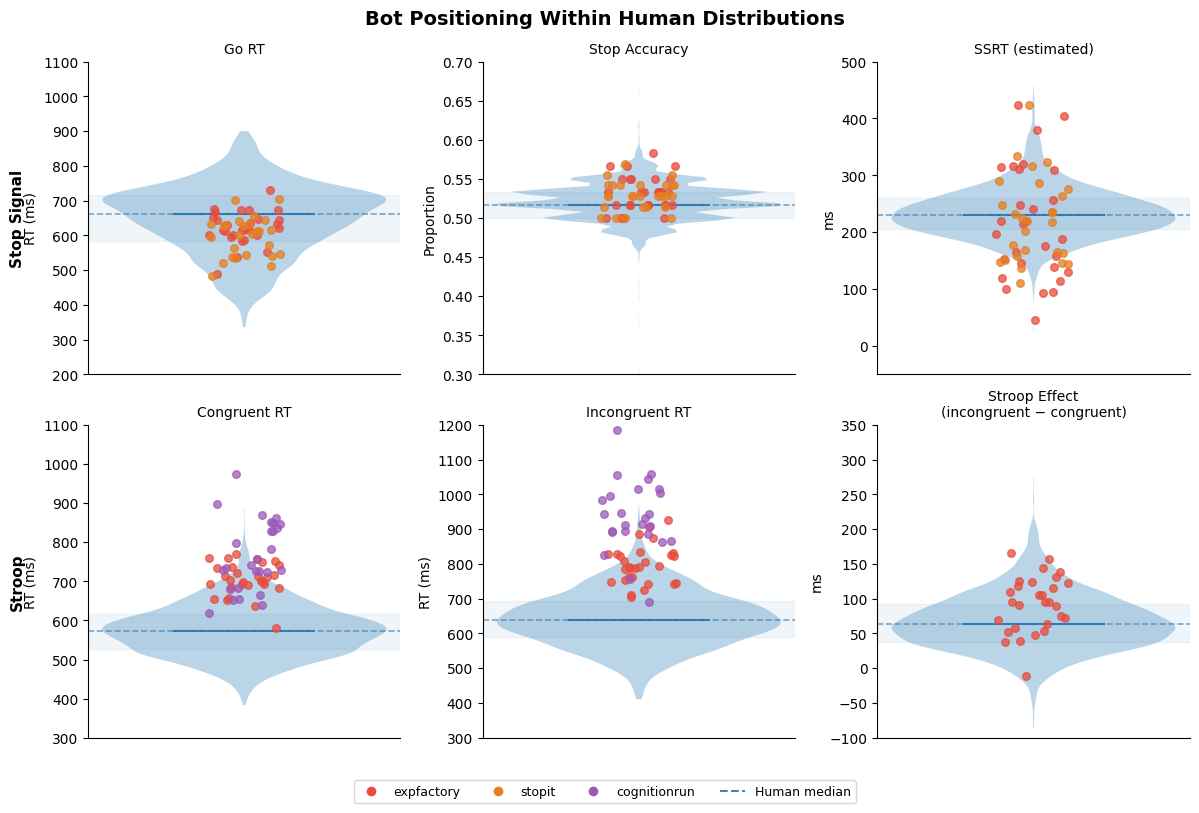

Saved figure1_bot_vs_human.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Bot Positioning Within Human Distributions", fontsize=14, fontweight='bold')

# --- Load and prepare data ---
bot_ss = pd.read_csv(OUTPUT_CSV_DIR / 'stop_signal.csv')
bot_st = pd.read_csv(OUTPUT_CSV_DIR / 'stroop.csv')

# Exclude extreme RT outliers from bot stop signal (go_rt > 2000ms)
bot_ss = bot_ss[bot_ss['go_rt'] < 2000].copy()

# Derive SSRT for both human and bot
ss_human_plot = ss_human.copy()
ss_human_plot['ssrt'] = pd.to_numeric(ss_human_plot['go_rt'], errors='coerce') - pd.to_numeric(ss_human_plot['mean_SSD'], errors='coerce')
bot_ss['ssrt'] = bot_ss['go_rt'] - bot_ss['mean_SSD']

stroop_human_plot = stroop_human.copy()
stroop_human_plot['stroop_effect'] = (
    pd.to_numeric(stroop_human_plot['incongruent_rt'], errors='coerce')
    - pd.to_numeric(stroop_human_plot['congruent_rt'], errors='coerce')
)
bot_ef_st = bot_st[bot_st['platform'] == 'expfactory'].copy()
bot_ef_st['stroop_effect'] = bot_ef_st['incongruent_rt'] - bot_ef_st['congruent_rt']
bot_ef_ss = bot_ss[bot_ss['platform'] == 'expfactory'].copy()

PLATFORM_COLORS = {'expfactory': '#e74c3c', 'stopit': '#e67e22', 'cognitionrun': '#9b59b6'}

def violin_with_bots(ax, human_series, bot_df, metric, bot_platform_col='platform',
                     ylabel='', title='', ylim=None):
    """Draw human violin + per-platform bot points."""
    human_vals = pd.to_numeric(human_series, errors='coerce').dropna()
    ax.violinplot(human_vals, positions=[0], widths=0.6, showmedians=True,
                  showextrema=False)
    # Shade human IQR
    q25, q75 = human_vals.quantile(0.25), human_vals.quantile(0.75)
    ax.axhspan(q25, q75, alpha=0.08, color='steelblue')
    ax.axhline(human_vals.median(), color='steelblue', linewidth=1.2, linestyle='--', alpha=0.7)

    for platform, color in PLATFORM_COLORS.items():
        subset = bot_df[bot_df[bot_platform_col] == platform]
        if len(subset) == 0:
            continue
        vals = pd.to_numeric(subset[metric], errors='coerce').dropna()
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(jitter, vals, color=color, alpha=0.75, s=30, zorder=3,
                   label=platform)

    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Row 1: Stop Signal ---
violin_with_bots(axes[0, 0], ss_human_plot['go_rt'], bot_ss, 'go_rt',
                 ylabel='RT (ms)', title='Go RT', ylim=(200, 1100))

violin_with_bots(axes[0, 1], ss_human_plot['stop_accuracy'], bot_ss, 'stop_accuracy',
                 ylabel='Proportion', title='Stop Accuracy', ylim=(0.3, 0.7))

violin_with_bots(axes[0, 2], ss_human_plot['ssrt'], bot_ss, 'ssrt',
                 ylabel='ms', title='SSRT (estimated)', ylim=(-50, 500))

# --- Row 2: Stroop ---
violin_with_bots(axes[1, 0], stroop_human_plot['congruent_rt'], bot_st, 'congruent_rt',
                 ylabel='RT (ms)', title='Congruent RT', ylim=(300, 1100))

violin_with_bots(axes[1, 1], stroop_human_plot['incongruent_rt'], bot_st, 'incongruent_rt',
                 ylabel='RT (ms)', title='Incongruent RT', ylim=(300, 1200))

violin_with_bots(axes[1, 2], stroop_human_plot['stroop_effect'], bot_ef_st, 'stroop_effect',
                 ylabel='ms', title='Stroop Effect\n(incongruent − congruent)', ylim=(-100, 350))

# Row labels
for ax, label in zip([axes[0, 0], axes[1, 0]], ['Stop Signal', 'Stroop']):
    ax.annotate(label, xy=(-0.25, 0.5), xycoords='axes fraction',
                fontsize=11, fontweight='bold', rotation=90, va='center')

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                       markersize=8, label=p)
           for p, c in PLATFORM_COLORS.items() if p in bot_ss['platform'].unique() or p in bot_st['platform'].unique()]
handles.append(plt.Line2D([0], [0], color='steelblue', linewidth=1.5,
                           linestyle='--', label='Human median'))
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(ROOT / 'scripts' / 'figure1_bot_vs_human.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure1_bot_vs_human.png")

## Figure 2: Sequential RT Effects
Trial-level analyses for both bot and human data. For each run/subject, compute (1) lag-1 RT autocorrelation and (2) post-error slowing. Bot data filtered to test trials; human data from Eisenberg et al. (2019) test trials. Post-error slowing computed only on consecutive trial pairs where both have valid RTs. Runs with extreme timing artifacts (mean go RT > 2000 ms) excluded.

In [ ]:
def load_test_trials_ss_rdoc(run_dir):
    """Load ALL test trials from one RDoC stop signal run in trial order.
    Includes both go and stop trials so that failed inhibitions (stop trials
    with correct_trial == 0 and a valid RT) can anchor post-error slowing."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test = df[df['trial_id'] == 'test_trial'].copy()
    test['rt'] = pd.to_numeric(test['rt'], errors='coerce')
    test['correct'] = pd.to_numeric(test['correct_trial'], errors='coerce')
    return test[['rt', 'correct']].reset_index(drop=True)

def load_test_trials_stopit(run_dir):
    """Load ALL test trials from one STOP-IT run in trial order.
    Includes both go (signal=='no') and stop (signal=='yes') trials.
    Omissions on go trials have response == 'undefined'."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    df['rt'] = pd.to_numeric(df['rt'], errors='coerce')
    df['correct'] = df['correct'].astype(float)
    df['omission'] = (df['signal'] == 'no') & (df['response'] == 'undefined')
    go = df[df['signal'] == 'no']
    if go['rt'].mean() > 2000:
        return None
    return df[['rt', 'correct', 'omission']].reset_index(drop=True)

def load_test_trials_stroop_rdoc(run_dir):
    """Load all test trials from one RDoC Stroop run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test = df[df['trial_id'] == 'test_trial'].copy()
    test['rt'] = pd.to_numeric(test['rt'], errors='coerce')
    test['correct'] = pd.to_numeric(test['correct_trial'], errors='coerce')
    return test[['rt', 'correct']].reset_index(drop=True)

def load_test_trials_cogrun(run_dir):
    """Load test trials from one Cognition.run Stroop run."""
    data_file = list(run_dir.glob('experiment_data.*'))[0]
    df = load_experiment_data(data_file)
    test = df[df['text'].notna()].copy()
    test['rt'] = pd.to_numeric(test['rt'], errors='coerce')
    test['correct'] = test.apply(
        lambda row: 1.0 if str(row['response']).lower() == str(row['colour'])[0].lower() else 0.0,
        axis=1
    )
    return test[['rt', 'correct']].reset_index(drop=True)

def lag1_autocorr(trials):
    """Lag-1 Pearson autocorrelation of valid (non-NaN) RT series."""
    rts = trials['rt'].dropna()
    if len(rts) < 3:
        return np.nan
    return rts.autocorr(lag=1)

def post_error_slowing(trials):
    """Post-error slowing: mean RT on trial N+1 after error vs. correct.
    Only considers consecutive trial pairs where BOTH have valid RTs.
    For STOP-IT data with an 'omission' column, omissions are excluded."""
    rt = trials['rt'].values.astype(float)
    correct = trials['correct'].values.astype(float)
    has_omission_col = 'omission' in trials.columns
    omission = trials['omission'].values if has_omission_col else np.zeros(len(trials), dtype=bool)

    after_error, after_correct = [], []
    for i in range(len(trials) - 1):
        if np.isnan(rt[i]) or np.isnan(rt[i + 1]):
            continue
        if omission[i] or omission[i + 1]:
            continue
        if correct[i] == 0:
            after_error.append(rt[i + 1])
        elif correct[i] == 1:
            after_correct.append(rt[i + 1])

    ae = np.mean(after_error) if len(after_error) > 0 else np.nan
    ac = np.mean(after_correct) if len(after_correct) > 0 else np.nan
    diff = ae - ac if not np.isnan(ae) and not np.isnan(ac) else np.nan
    return ae, ac, diff

# ===== BOT sequential effects =====
bot_records = []

for run_dir in find_all_runs('stop_signal_task_(rdoc)'):
    try:
        trials = load_test_trials_ss_rdoc(run_dir)
        if trials is None or len(trials) == 0: continue
        ac = lag1_autocorr(trials)
        _, _, pes = post_error_slowing(trials)
        bot_records.append({'task': 'Stop Signal', 'platform': 'ExpFactory',
                            'autocorr': ac, 'pes_ms': pes, 'source': 'bot'})
    except Exception: pass

for run_dir in find_all_runs_by_name('stop-signal_task_(stop-it)'):
    try:
        trials = load_test_trials_stopit(run_dir)
        if trials is None or len(trials) == 0: continue
        ac = lag1_autocorr(trials)
        _, _, pes = post_error_slowing(trials)
        bot_records.append({'task': 'Stop Signal', 'platform': 'STOP-IT',
                            'autocorr': ac, 'pes_ms': pes, 'source': 'bot'})
    except Exception: pass

for run_dir in find_all_runs_by_name('stroop_(rdoc)'):
    try:
        trials = load_test_trials_stroop_rdoc(run_dir)
        if trials is None or len(trials) == 0: continue
        ac = lag1_autocorr(trials)
        _, _, pes = post_error_slowing(trials)
        bot_records.append({'task': 'Stroop', 'platform': 'ExpFactory',
                            'autocorr': ac, 'pes_ms': pes, 'source': 'bot'})
    except Exception: pass

for run_dir in find_all_runs_by_name('stroop_online'):
    try:
        trials = load_test_trials_cogrun(run_dir)
        if trials is None or len(trials) == 0: continue
        ac = lag1_autocorr(trials)
        _, _, pes = post_error_slowing(trials)
        bot_records.append({'task': 'Stroop', 'platform': 'Cognition.run',
                            'autocorr': ac, 'pes_ms': pes, 'source': 'bot'})
    except Exception: pass

# ===== HUMAN sequential effects (Eisenberg 2019) =====
# Only computed if trial-level data is available (USING_TRIAL_LEVEL flag from cell 3)
human_records = []

# Stop signal: all test trials per subject in trial order
for subj, sdf in (ss_test.groupby('worker_id') if USING_TRIAL_LEVEL and len(ss_test) > 0 else []):
    sdf = sdf.sort_values('trial_num').copy()
    sdf['correct'] = sdf['correct'].astype(float)
    # Stopped go trials (omissions) have no valid RT for PES anchoring
    sdf_valid = sdf[['rt', 'correct']].reset_index(drop=True)
    ac = lag1_autocorr(sdf_valid)
    _, _, pes = post_error_slowing(sdf_valid)
    human_records.append({'task': 'Stop Signal', 'autocorr': ac, 'pes_ms': pes, 'source': 'human'})

# Stroop: all test trials per subject in trial order
for subj, sdf in (stroop_test.groupby('worker_id') if USING_TRIAL_LEVEL and len(stroop_test) > 0 else []):
    sdf = sdf.sort_values('trial_num') if 'trial_num' in sdf.columns else sdf
    sdf = sdf.copy()
    sdf['correct'] = sdf['correct'].astype(float)
    sdf_valid = sdf[['rt', 'correct']].reset_index(drop=True)
    ac = lag1_autocorr(sdf_valid)
    _, _, pes = post_error_slowing(sdf_valid)
    human_records.append({'task': 'Stroop', 'autocorr': ac, 'pes_ms': pes, 'source': 'human'})

bot_seq = pd.DataFrame(bot_records)
human_seq = pd.DataFrame(human_records)

print("=== Bot Sequential Effects ===")
for (task,), grp in (bot_seq.groupby(['task']) if len(bot_seq) > 0 else []):
    ac = grp['autocorr'].dropna()
    pes = grp['pes_ms'].dropna()
    print(f"{task} (n={len(grp)}): autocorr={ac.mean():.3f} ± {ac.std():.3f}, PES={pes.mean():.1f} ± {pes.std():.1f} ms")

print("\n=== Human Sequential Effects (Eisenberg 2019) ===")
if len(human_seq) == 0:
    print("  (no trial-level human data available — download Eisenberg 2019 CSVs)")
for task, grp in (human_seq.groupby('task') if len(human_seq) > 0 else []):
    ac = grp['autocorr'].dropna()
    pes = grp['pes_ms'].dropna()
    print(f"{task} (n={len(grp)}): autocorr={ac.mean():.3f} ± {ac.std():.3f}, PES={pes.mean():.1f} ± {pes.std():.1f} ms")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

BOT_COLORS = {'Stop Signal / ExpFactory': '#c0392b', 'Stop Signal / STOP-IT': '#e67e22',
              'Stroop / ExpFactory': '#2980b9', 'Stroop / Cognition.run': '#9b59b6'}

# Plot human as violin backgrounds
for task_idx, task_name in enumerate(['Stop Signal', 'Stroop']):
    if len(human_seq) == 0:
        h_sub = pd.DataFrame(columns=['task', 'autocorr', 'pes_ms'])
    else:
        h_sub = human_seq[human_seq['task'] == task_name]

    # Autocorrelation violin
    ac_vals = h_sub['autocorr'].dropna().values
    if len(ac_vals) > 5:
        vp = axes[0].violinplot(ac_vals, positions=[task_idx], widths=0.5,
                                showmedians=True, showextrema=False)
        for body in vp['bodies']:
            body.set_facecolor('lightgray')
            body.set_alpha(0.5)

    # PES violin
    pes_vals = h_sub['pes_ms'].dropna().values
    if len(pes_vals) > 5:
        vp = axes[1].violinplot(pes_vals, positions=[task_idx], widths=0.5,
                                showmedians=True, showextrema=False)
        for body in vp['bodies']:
            body.set_facecolor('lightgray')
            body.set_alpha(0.5)

# Plot bot as colored points
for _, row in (bot_seq.iterrows() if len(bot_seq) > 0 else []):
    key = f"{row['task']} / {row['platform']}"
    color = BOT_COLORS.get(key, 'gray')
    x_pos = 0 if row['task'] == 'Stop Signal' else 1
    jitter = np.random.uniform(-0.08, 0.08)

    if not np.isnan(row['autocorr']):
        axes[0].scatter(x_pos + jitter, row['autocorr'], color=color, alpha=0.7, s=30, zorder=3)
    if not np.isnan(row['pes_ms']):
        axes[1].scatter(x_pos + jitter, row['pes_ms'], color=color, alpha=0.7, s=30, zorder=3)

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

axes[0].set_title('Lag-1 RT Autocorrelation', fontsize=11)
axes[0].set_ylabel('Pearson r', fontsize=10)
axes[1].set_title('Post-Error Slowing', fontsize=11)
axes[1].set_ylabel('RT difference (ms)\n(after error − after correct)', fontsize=10)

for ax in axes:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Stop Signal', 'Stroop'], fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                       markersize=7, label=lbl) for lbl, c in BOT_COLORS.items()]
handles.append(plt.Line2D([0], [0], color='lightgray', linewidth=8, alpha=0.5, label='Human (Eisenberg 2019)'))
axes[0].legend(handles=handles, fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(ROOT / 'scripts' / 'figure2_sequential_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure2_sequential_effects.png")